<a href="https://colab.research.google.com/github/AKakatii-08/Cosmology-Second-project/blob/main/Hardenig%20time%20contour%20plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm

Computing luminosity distance grid...


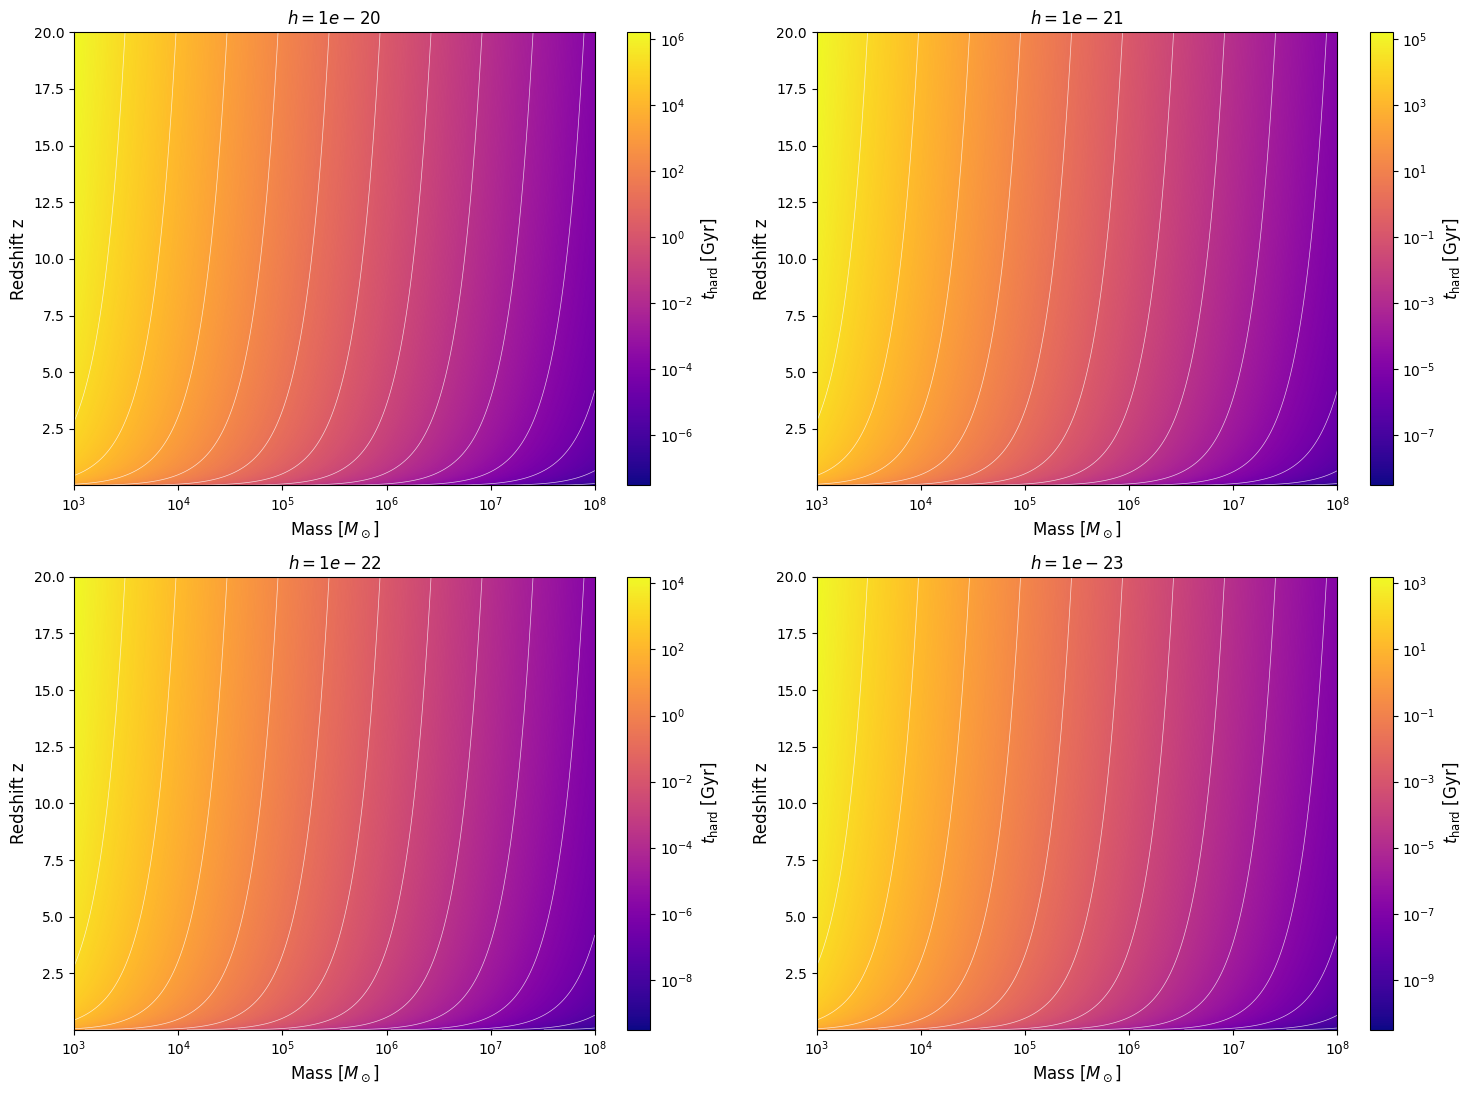

In [18]:
# =========================================================
# LCDM Smooth Contour Plot for Hardening Timescale
# 2x2 Quadrant Plot for Different Strain Values
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants (SI Units)
# =========================================================

G = 6.67430e-11
c = 3e8

M_sun = 2e30
pc = 3.086e16

# Hardening constant
H_const = 14.3

# =========================================================
# Cosmological Parameters (LCDM)
# =========================================================

H0 = 67.4 * 1000 / (3.086e22)   # s^-1
Omega_m = 0.315
Omega_L = 0.6847

# =========================================================
# Galaxy Parameters
# =========================================================

sigma = 100 * 1000      # velocity dispersion (m/s)

rho = 1e6               # Msun / pc^3

# Convert density to SI
rho1 = rho * M_sun / (pc**3)

# =========================================================
# LCDM Hubble Function
# =========================================================

def H_z(z):

    return H0 * np.sqrt(
        Omega_m * (1 + z)**3 +
        Omega_L
    )

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: c / H_z(zp),
        0,
        z
    )

    return (1 + z) * integral

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(3, 8, 1000)      # Msun
redshift = np.linspace(0.01, 20, 1000)

M, Z = np.meshgrid(mass, redshift)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

print("Computing luminosity distance grid...")

dL_1D = np.array([
    luminosity_distance(z)
    for z in redshift
])

# Expand to 2D grid
dL = np.tile(
    dL_1D[:, np.newaxis],
    (1, len(mass))
)

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Figure
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12)
)

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (G**2 * Mkg**2) / (
        c**4 * h * dL
    )

    # =====================================================
    # Hardening Timescale
    # =====================================================

    t_hard = sigma / (
        H_const * G * rho1 * a
    )

    # Convert to Gyr
    t_hard_Gyr = t_hard / (
        60 * 60 * 24 * 365 * 1e9
    )

    # =====================================================
    # Smooth Background
    # =====================================================

    mesh = ax.pcolormesh(
        M,
        Z,
        t_hard_Gyr,
        shading='gouraud',
        cmap='plasma',
        norm=LogNorm(),
        antialiased=True
    )

    # =====================================================
    # Contour Lines
    # =====================================================

    contour_levels = np.logspace(
        np.log10(t_hard_Gyr.min()),
        np.log10(t_hard_Gyr.max()),
        15
    )

    lines = ax.contour(
        M,
        Z,
        t_hard_Gyr,
        levels=contour_levels,
        colors='white',
        linewidths=0.5,
        alpha=0.75
    )

    # Optional contour labels
    # ax.clabel(lines, fontsize=7)

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        r"Mass [$M_\odot$]",
        fontsize=12
    )

    ax.set_ylabel(
        "Redshift z",
        fontsize=12
    )

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=12
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(
        r"$t_{\mathrm{hard}}$ [Gyr]",
        fontsize=12
    )

# =========================================================
# Main Title
# =========================================================



plt.tight_layout(
    rect=[0, 0.03, 1, 0.95]
)

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "LCDM_t_hard_smooth_contour.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

WCDM

Computing luminosity distance grid...


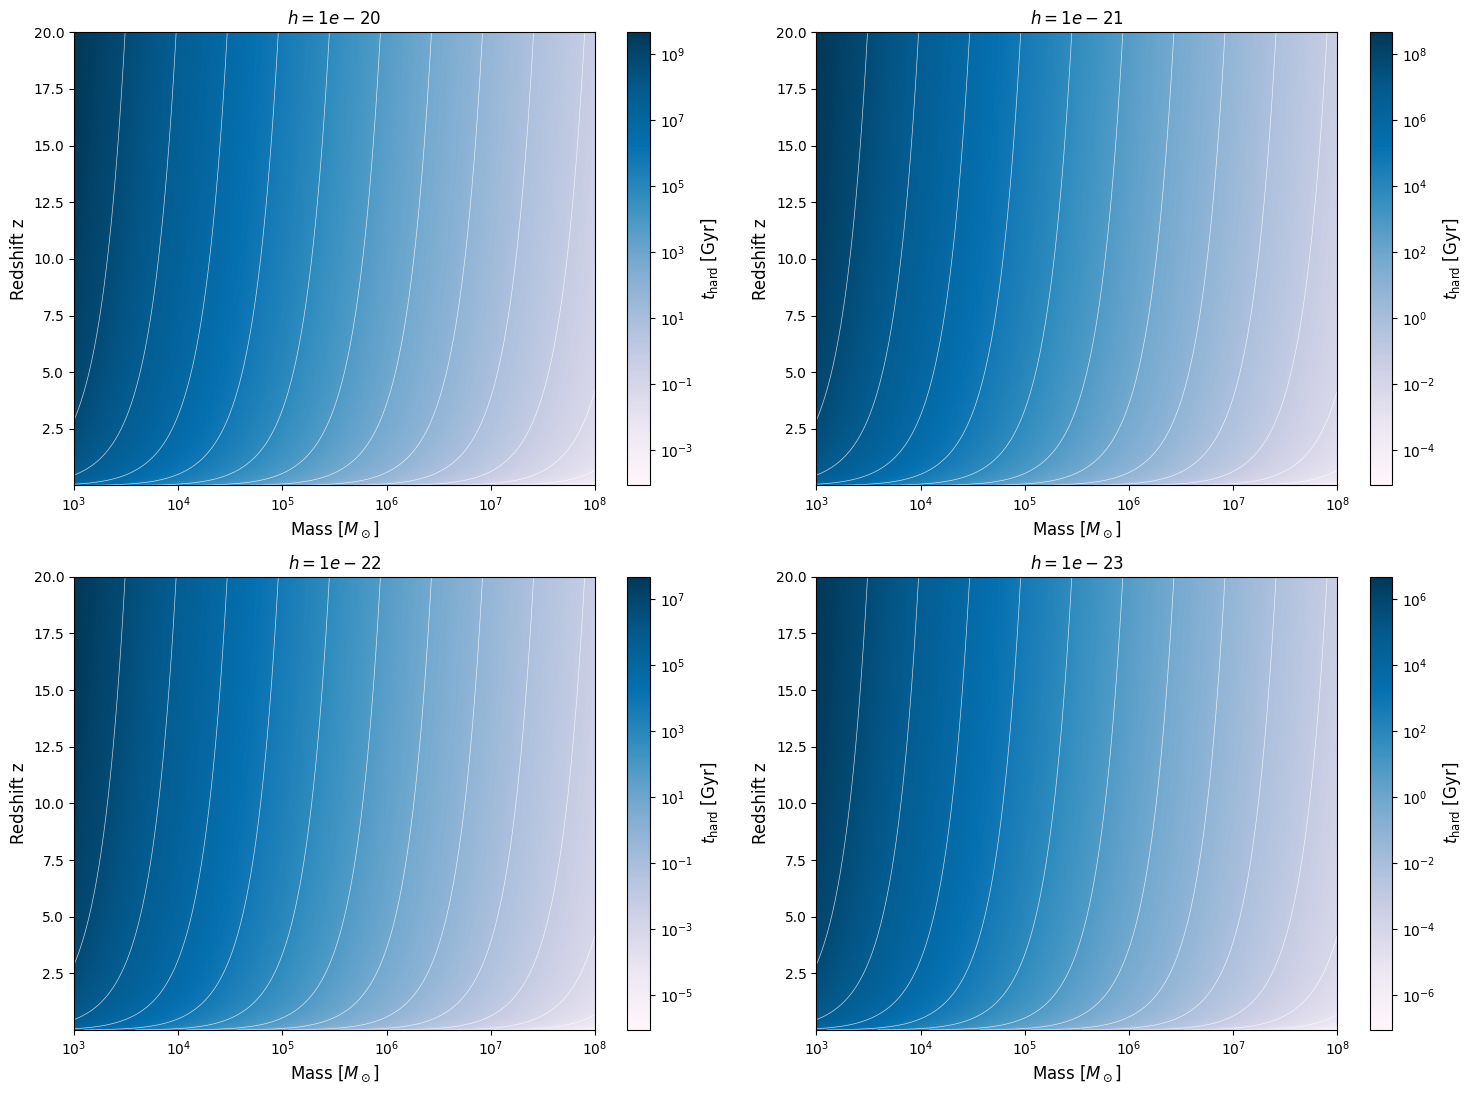

In [22]:
# =========================================================
# wCDM Smooth Contour Plot for Hardening Timescale
# 2x2 Quadrant Plot for Different Strain Values
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants (SI Units)
# =========================================================

G = 6.67430e-11
c = 3e8

M_sun = 2e30
pc = 3.086e16

# Hardening constant
H_const = 14.3

# =========================================================
# USER INPUT (wCDM)
# =========================================================

sigma = 300 * 1000      # velocity dispersion (m/s)

rho = 1e3               # density (Msun / pc^3)

# Convert density to SI
rho1 = rho * M_sun / (pc**3)

# =========================================================
# wCDM Cosmological Parameters
# =========================================================

H0 = 71.1 * 1000 / (3.086e22)

Omega_m = 0.264
Omega_de = 0.736

w = -0.80

# =========================================================
# wCDM Hubble Function
# =========================================================

def H_z_wcdm(z):

    return H0 * np.sqrt(
        Omega_m * (1 + z)**3 +
        Omega_de * (1 + z)**(3 * (1 + w))
    )

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: c / H_z_wcdm(zp),
        0,
        z
    )

    return (1 + z) * integral

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(3, 8, 1000)

redshift = np.linspace(0.01, 20, 1000)

M, Z = np.meshgrid(
    mass,
    redshift
)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

print("Computing luminosity distance grid...")

dL_1D = np.array([
    luminosity_distance(z)
    for z in redshift
])

# Expand to 2D grid
dL = np.tile(
    dL_1D[:, np.newaxis],
    (1, len(mass))
)

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Figure
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12)
)

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (
        G**2 * Mkg**2
    ) / (
        c**4 * h * dL
    )

    # =====================================================
    # Hardening Timescale
    # =====================================================

    t_hard = sigma / (
        H_const * G * rho1 * a
    )

    # Convert to Gyr
    t_hard_Gyr = t_hard / (
        60 * 60 * 24 * 365 * 1e9
    )

    # =====================================================
    # Smooth Background
    # =====================================================

    mesh = ax.pcolormesh(
        M,
        Z,
        t_hard_Gyr,
        shading='gouraud',
        cmap='PuBu',
        norm=LogNorm(),
        antialiased=True
    )

    # =====================================================
    # Contour Lines
    # =====================================================

    contour_levels = np.logspace(
        np.log10(t_hard_Gyr.min()),
        np.log10(t_hard_Gyr.max()),
        15
    )

    lines = ax.contour(
        M,
        Z,
        t_hard_Gyr,
        levels=contour_levels,
        colors='white',
        linewidths=0.5,
        alpha=0.75
    )

    # Optional contour labels
    # ax.clabel(lines, fontsize=7)

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        r"Mass [$M_\odot$]",
        fontsize=12
    )

    ax.set_ylabel(
        "Redshift z",
        fontsize=12
    )

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=12
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(
        r"$t_{\mathrm{hard}}$ [Gyr]",
        fontsize=12
    )

# =========================================================
# Main Title
# =========================================================



plt.tight_layout(
    rect=[0, 0.03, 1, 0.95]
)

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "wCDM_t_hard_smooth_contour.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

BRANE WORLD

Computing luminosity distance grid...


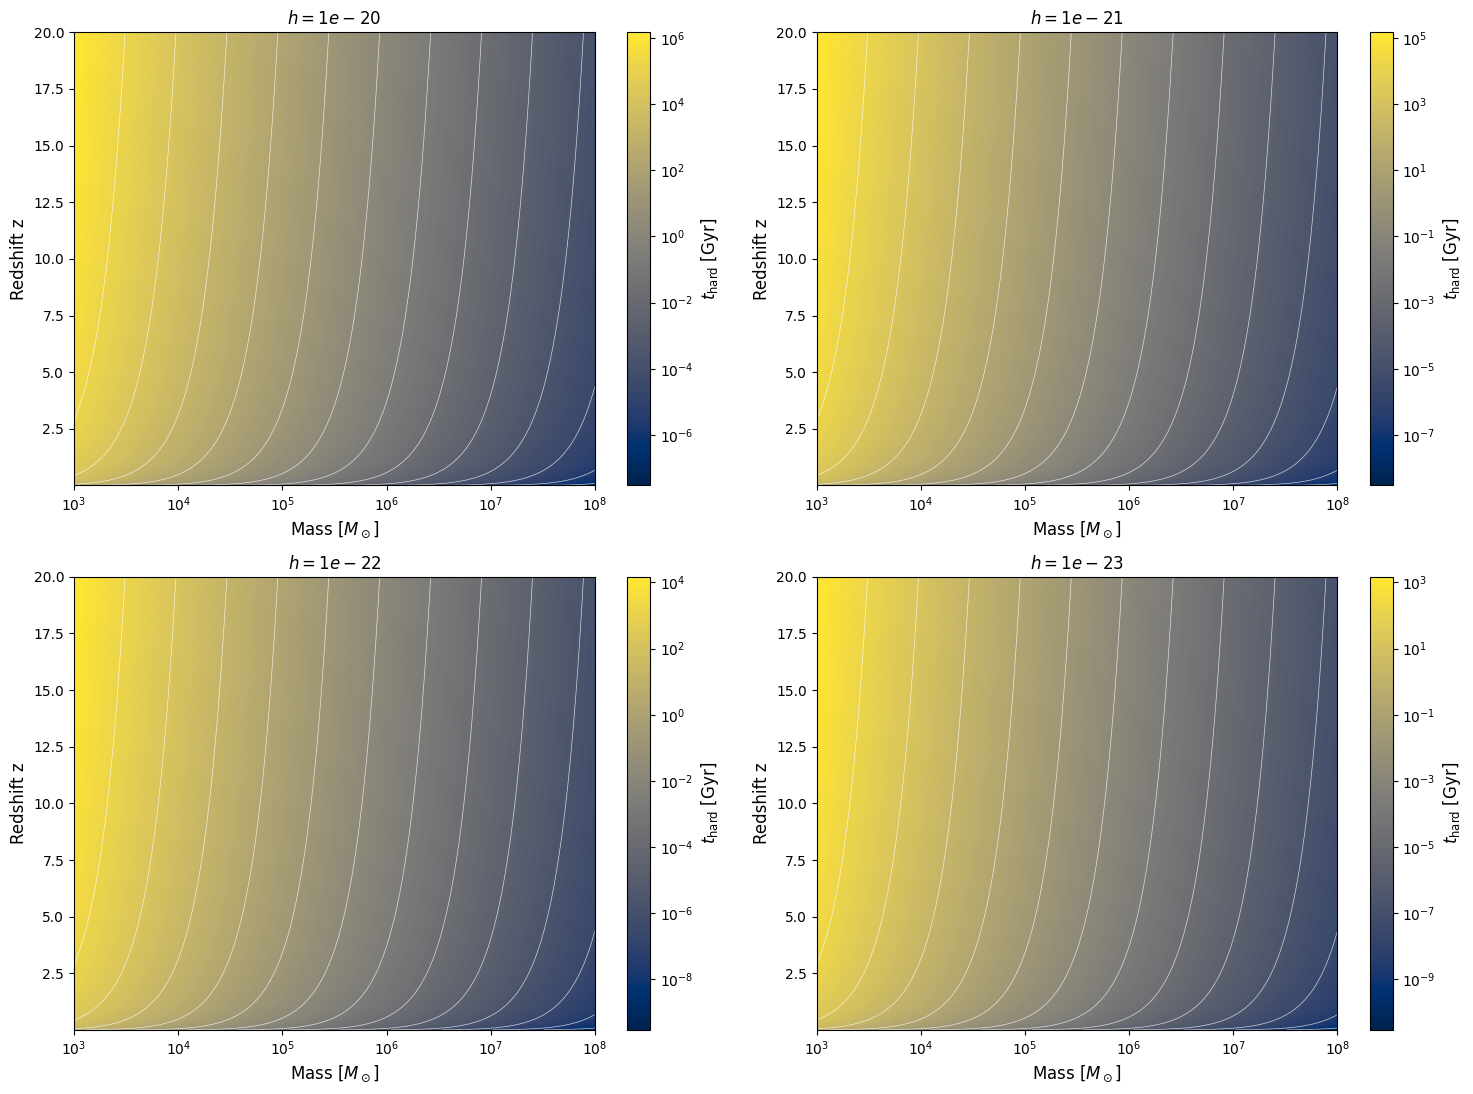

In [20]:
# =========================================================
# Brane World (DGP) Smooth Contour Plot
# Hardening Timescale t_hard
# 2x2 Quadrant Plot for Different Strain Values
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants (SI Units)
# =========================================================

G = 6.67430e-11
c = 3e8

M_sun = 2e30
pc = 3.086e16

# Hardening constant
H_const = 14.3

# =========================================================
# USER INPUT (Brane World / DGP)
# =========================================================

sigma = 100 * 1000      # velocity dispersion (m/s)

rho = 1e6               # density (Msun / pc^3)

# Convert density to SI
rho1 = rho * M_sun / (pc**3)

# =========================================================
# DGP Cosmological Parameters
# =========================================================

H0 = 69.08 * 1000 / (3.086e22)

Omega_m = 0.3

# Flat DGP parameter
Omega_rc = ((1 - Omega_m) / 2)**2

# =========================================================
# DGP Hubble Function
# =========================================================

def H_z_dgp(z):

    return H0 * (
        np.sqrt(
            Omega_m * (1 + z)**3 +
            Omega_rc
        )
        + np.sqrt(Omega_rc)
    )

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: c / H_z_dgp(zp),
        0,
        z
    )

    return (1 + z) * integral

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(3, 8, 1000)

redshift = np.linspace(0.01, 20, 1000)

M, Z = np.meshgrid(
    mass,
    redshift
)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

print("Computing luminosity distance grid...")

dL_1D = np.array([
    luminosity_distance(z)
    for z in redshift
])

# Expand to 2D grid
dL = np.tile(
    dL_1D[:, np.newaxis],
    (1, len(mass))
)

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Figure
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12)
)

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (
        G**2 * Mkg**2
    ) / (
        c**4 * h * dL
    )

    # =====================================================
    # Hardening Timescale
    # =====================================================

    t_hard = sigma / (
        H_const * G * rho1 * a
    )

    # Convert to Gyr
    t_hard_Gyr = t_hard / (
        60 * 60 * 24 * 365 * 1e9
    )

    # =====================================================
    # Smooth Background
    # =====================================================

    mesh = ax.pcolormesh(
        M,
        Z,
        t_hard_Gyr,
        shading='gouraud',
        cmap='cividis',
        norm=LogNorm(),
        antialiased=True
    )

    # =====================================================
    # Contour Lines
    # =====================================================

    contour_levels = np.logspace(
        np.log10(t_hard_Gyr.min()),
        np.log10(t_hard_Gyr.max()),
        15
    )

    lines = ax.contour(
        M,
        Z,
        t_hard_Gyr,
        levels=contour_levels,
        colors='white',
        linewidths=0.5,
        alpha=0.75
    )

    # Optional contour labels
    # ax.clabel(lines, fontsize=7)

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        r"Mass [$M_\odot$]",
        fontsize=12
    )

    ax.set_ylabel(
        "Redshift z",
        fontsize=12
    )

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=12
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(
        r"$t_{\mathrm{hard}}$ [Gyr]",
        fontsize=12
    )

# =========================================================
# Main Title
# =========================================================



plt.tight_layout(
    rect=[0, 0.03, 1, 0.95]
)

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "DGP_t_hard_smooth_contour.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

DDE

Computing luminosity distance grid...


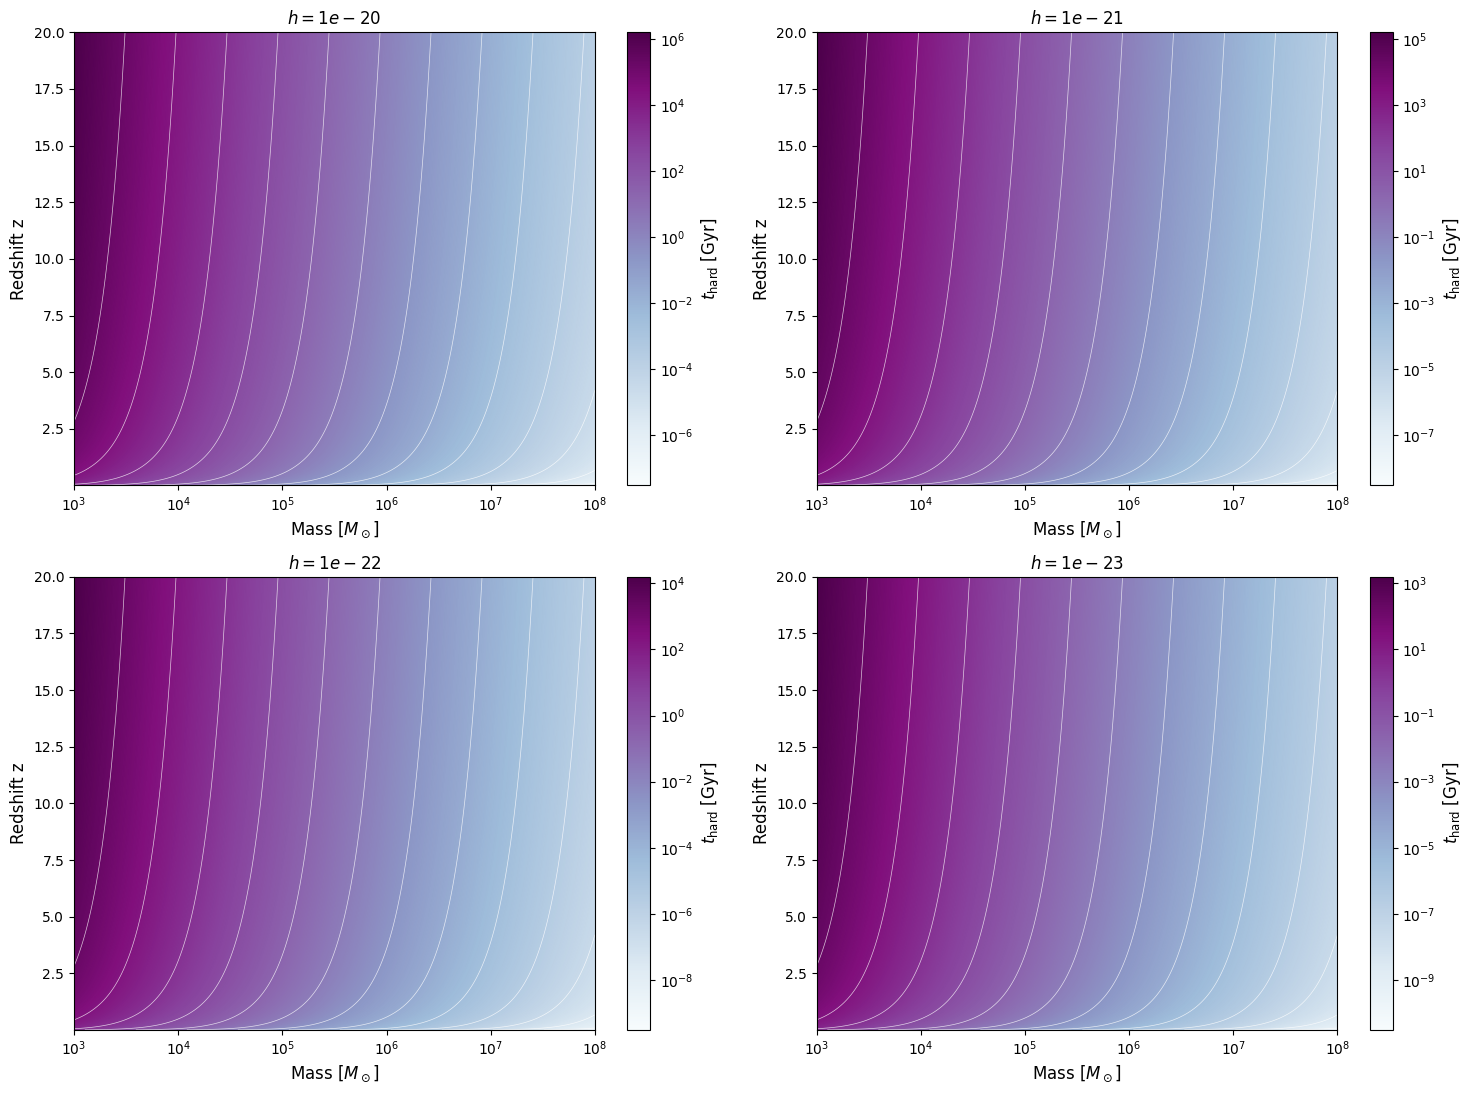

In [21]:
# =========================================================
# DDE Smooth Contour Plot
# Hardening Timescale t_hard
# 2x2 Quadrant Plot for Different Strain Values
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, NullLocator

# =========================================================
# Physical Constants (SI Units)
# =========================================================

G = 6.67430e-11
c = 3e8

M_sun = 2e30
pc = 3.086e16

# Hardening constant
H_const = 14.3

# =========================================================
# USER INPUT (DDE Cosmology)
# =========================================================

sigma = 100 * 1000      # velocity dispersion (m/s)

rho = 1e6               # density (Msun / pc^3)

# Convert density to SI
rho1 = rho * M_sun / (pc**3)

# =========================================================
# DDE Cosmological Parameters
# =========================================================

H0 = 67.22 * 1000 / (3.086e22)

Omega_m = 0.3161
Omega_de = 1 - Omega_m

w0 = -0.726
wa = -1.05

# =========================================================
# DDE Hubble Function
# =========================================================

def H_z_dde(z):

    de_factor = (
        (1 + z)**(3 * (1 + w0 + wa))
        * np.exp(
            -3 * wa * z / (1 + z)
        )
    )

    return H0 * np.sqrt(
        Omega_m * (1 + z)**3 +
        Omega_de * de_factor
    )

# =========================================================
# Luminosity Distance
# =========================================================

def luminosity_distance(z):

    integral, _ = quad(
        lambda zp: c / H_z_dde(zp),
        0,
        z
    )

    return (1 + z) * integral

# =========================================================
# Parameter Space
# =========================================================

mass = np.logspace(3, 8, 1000)

redshift = np.linspace(0.01, 20, 1000)

M, Z = np.meshgrid(
    mass,
    redshift
)

# Convert mass to kg
Mkg = M * M_sun

# =========================================================
# Compute Luminosity Distance Grid
# =========================================================

print("Computing luminosity distance grid...")

dL_1D = np.array([
    luminosity_distance(z)
    for z in redshift
])

# Expand to 2D grid
dL = np.tile(
    dL_1D[:, np.newaxis],
    (1, len(mass))
)

# =========================================================
# Different Strain Values
# =========================================================

strain_values = [1e-20, 1e-21, 1e-22, 1e-23]

# =========================================================
# Create 2x2 Figure
# =========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 12)
)

axes = axes.flatten()

# =========================================================
# Main Loop
# =========================================================

for ax, h in zip(axes, strain_values):

    # =====================================================
    # Separation Distance
    # =====================================================

    a = (
        G**2 * Mkg**2
    ) / (
        c**4 * h * dL
    )

    # =====================================================
    # Hardening Timescale
    # =====================================================

    t_hard = sigma / (
        H_const * G * rho1 * a
    )

    # Convert to Gyr
    t_hard_Gyr = t_hard / (
        60 * 60 * 24 * 365 * 1e9
    )

    # =====================================================
    # Smooth Background
    # =====================================================

    mesh = ax.pcolormesh(
        M,
        Z,
        t_hard_Gyr,
        shading='gouraud',
        cmap='BuPu',
        norm=LogNorm(),
        antialiased=True
    )

    # =====================================================
    # Contour Lines
    # =====================================================

    contour_levels = np.logspace(
        np.log10(t_hard_Gyr.min()),
        np.log10(t_hard_Gyr.max()),
        15
    )

    lines = ax.contour(
        M,
        Z,
        t_hard_Gyr,
        levels=contour_levels,
        colors='white',
        linewidths=0.5,
        alpha=0.75
    )

    # Optional contour labels
    # ax.clabel(lines, fontsize=7)

    # =====================================================
    # Logarithmic x-axis
    # =====================================================

    ax.set_xscale("log")

    ax.xaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.xaxis.set_minor_locator(
        NullLocator()
    )

    # =====================================================
    # Labels
    # =====================================================

    ax.set_xlabel(
        r"Mass [$M_\odot$]",
        fontsize=12
    )

    ax.set_ylabel(
        "Redshift z",
        fontsize=12
    )

    # =====================================================
    # Title
    # =====================================================

    ax.set_title(
        rf"$h = {h:.0e}$",
        fontsize=12
    )

    # =====================================================
    # Colorbar
    # =====================================================

    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(
        r"$t_{\mathrm{hard}}$ [Gyr]",
        fontsize=12
    )

# =========================================================
# Main Title
# =========================================================


plt.tight_layout(
    rect=[0, 0.03, 1, 0.95]
)

# =========================================================
# Save Figure
# =========================================================

plt.savefig(
    "DDE_t_hard_smooth_contour.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()